In [1]:
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
pd.set_option('display.max_columns', None)
import time
import warnings
warnings.filterwarnings("ignore")
import os
import sys

In [ ]:
sys.path.append('illume_plus/')

In [3]:
import data_utils
import models

In [4]:
from expl_utils import inverse_transform_rule_complete

# Load Drug Dataset

In [5]:
# drug_folder_number = 1010 # Gefitinib
# drug_folder_number = 1011 # Navitoclax
# drug_folder_number = 1051 # Alisertib
# drug_folder_number = 1909 # Venetoclax
drug_folder_number = 1168 # Erlotinib

base_data_path = 'data/'

In [6]:
full_path_columns = base_data_path + f'/gdsc/{drug_folder_number}/splits/columns_Boruta.csv'
full_path_trasc = base_data_path + f'/transcriptomics.feather'
full_path_splits = base_data_path + f'/gdsc/{drug_folder_number}/splits/'
full_lgbm_preds = base_data_path + f'/gdsc/{drug_folder_number}/classification/'

In [7]:
# Load transcriptomics data once
ordered_features = data_utils.load_feature_order(full_path_columns) # this is the list of genes found in the file columns
transcriptomics_indexed = data_utils.load_transcriptomics_data(full_path_trasc)  # this is a df that associates ALL genes to all cell lines
transcriptomics_indexed = data_utils.filter_transcriptomics_by_genes(transcriptomics_indexed, ordered_features) #filter the transcriptomics df
feature_names = np.array(ordered_features)

Loading feature order from data//gdsc/1168/splits/columns_Boruta.csv...
Number of ordered features: 1134
Loading transcriptomics data from data//transcriptomics.feather...
Transcriptomics shape: (14197, 18176)
Filtering transcriptomics data by top genes...
Transcriptomics columns: 18174
Top genes found: 1134 out of 1134
Filtered transcriptomics shape: (14197, 1134)
Original shape was: (14197, 18174)


In [8]:
# train dataset
train_data = data_utils.process_dataset('train', full_path_splits, transcriptomics_indexed, feature_names, 
                            fit_scaler=True)

# Process test set (use training scaler)
test_data = data_utils.process_dataset('test', full_path_splits, transcriptomics_indexed, feature_names, 
                        scaler=train_data['scaler'], fit_scaler=False) 

# Process validation set (use training scaler)  
val_data = data_utils.process_dataset('valid', full_path_splits, transcriptomics_indexed, feature_names, 
                            scaler=train_data['scaler'], fit_scaler=False)


=== PROCESSING TRAIN DATASET ===
Loading instance names from data//gdsc/1168/splits/train_X.csv...
Loaded 583 instances
First few instances: ['ACH-001711' 'ACH-000087' 'ACH-000644']
Loading labels/predictions from data//gdsc/1168/splits/train_Y.csv...
Loaded 583 labels/predictions
First few values: [-0.5232259  -0.91616097  0.73936869]
Creating feature matrix...
Columns entries found among genes: 1134 out of 1134
All cell lines (instances) in splits are in transcriptomics
Feature matrix shape: (583, 1134)
Applying standard scaling...
Before scaling - Mean: 0.0015, Std: 1.0686
Fitted new scaler on training data
After scaling - Mean: -0.0000, Std: 1.0000
Final train dataset - X: (583, 1134), y: (583,)

=== PROCESSING TEST DATASET ===
Loading instance names from data//gdsc/1168/splits/test_X.csv...
Loaded 48 instances
First few instances: ['ACH-001334' 'ACH-000075' 'ACH-000021']
Loading labels/predictions from data//gdsc/1168/splits/test_Y.csv...
Loaded 48 labels/predictions
First few va

In [9]:
# Load (X, Y) for the original regression task
X_train = train_data['X']  # Shape: (n_train_samples, n_features)
Y_train = train_data['y']  # Shape: (n_train_samples,)
X_test = test_data['X']    # Shape: (n_test_samples, n_features) 
Y_test = test_data['y']    # Shape: (n_test_samples,)
X_val = val_data['X']      # Shape: (n_val_samples, n_features)
Y_val = val_data['y']      # Shape: (n_val_samples,)

In [10]:
# Label binning for Y
from sklearn.preprocessing import KBinsDiscretizer
kbd = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile').fit(Y_train.reshape(-1, 1))
Y_train = kbd.transform(Y_train.reshape(-1, 1)).flatten().astype(int)
Y_test = kbd.transform(Y_test.reshape(-1, 1)).flatten().astype(int)
Y_val = kbd.transform(Y_val.reshape(-1, 1)).flatten().astype(int)

In [11]:
# Load predict_proba from pretrained LGBM --or train a different black-box on (X_train, Y_train) 

# from utils import lgbm_optuna_eval
# best_clf, _ = lgbm_optuna_eval(X_train, Y_train, X_val, Y_val)
# Y_train_pred = best_clf.predict_proba(X_train)
# Y_test_pred = best_clf.predict_proba(X_test)
# Y_val_pred = best_clf.predict_proba(X_val)

Y_train_pred = data_utils.load_probas_predictions(full_lgbm_preds+'train_preds.csv')
Y_test_pred = data_utils.load_probas_predictions(full_lgbm_preds+'test_preds.csv')
Y_val_pred = data_utils.load_probas_predictions(full_lgbm_preds+'valid_preds.csv')

Loading labels/predictions from data//gdsc/1168/classification/train_preds.csv...
Loaded 583 labels/predictions
First few values: [[0.28533257 0.38215022 0.33251722]
 [0.31303086 0.41949915 0.26746999]
 [0.16927845 0.35854865 0.4721729 ]]
Loading labels/predictions from data//gdsc/1168/classification/test_preds.csv...
Loaded 48 labels/predictions
First few values: [[0.45727991 0.29752722 0.24519287]
 [0.15191994 0.30814421 0.53993585]
 [0.33292502 0.25289751 0.41417747]]
Loading labels/predictions from data//gdsc/1168/classification/valid_preds.csv...
Loaded 44 labels/predictions
First few values: [[0.22024669 0.39926795 0.38048537]
 [0.45882337 0.29254117 0.24863546]
 [0.31995599 0.38310796 0.29693604]]


In [11]:
# Black-box predicted labels
Y_train_bb = np.argmax(Y_train_pred, axis=1)
Y_test_bb = np.argmax(Y_test_pred, axis=1)
Y_val_bb = np.argmax(Y_val_pred, axis=1)
idx_num_cat = [[i] for i in range(X_train.shape[1])]

# Latent Encoding Training

## Run the code for training a dense meta-encoding.

In [ ]:
latent = models.ILLUMEplus(max_epochs=500, 
                       latent_dim=96, 
                       rank_dim=None, # None automatically set rank_dim=sqrt(input_dim)
                       batch_size=64)

Important inputs:
- X=(X_train, X_test) : train/validation sets for validation accuracy / early stopping
- y=(y_train_pred, y_test_pred) : predicted black-box probabilities (optional)
- idx_num_cat : list of lists with numerical/categorical features indices
- params_dict : dictionary with regularization parameters

Keys in params_dict:
- 'num_k': number of non-zero weights per row in the encoder transformation matrix. None means all non-zero weights  
- 'l_so': set to 1.0 to enable orthogonalization of the encoder transformation matrix (only if 'num_k'!= None) 
- 'l_rec': set to 1.0 to enable training a non-linear decoder 
- 'l_kld': set to 1.0 to optimize distances distribution
- 'l_co': set to 1.0 to optimize non-collinearity of latent features
- 'l_st': set to 1.0 to optimize local stability of individual linear transformations (only if encdec='param_encdec')

In [14]:
losses = latent.fit(X=(X_train, X_val),                   
                    y=(Y_train_pred, Y_val_pred),               
                    idx_num_cat=idx_num_cat,                       
                    params_dict={'num_k':None, 'l_rec':0.0, 'l_kld':1.0,      # dictionary with regularization parameters
                            'l_so':0.0, 'l_co':0.0, 'l_st':0.1},
                    seed=42)

num. parameters = 3631068
Training Meta-encoder with max 500 iterations.


Epoch: 125 Train Loss 0.00579 Test Loss 0.00851 Early Stopping 30

Text(0.5, 1.0, 'Space Z')

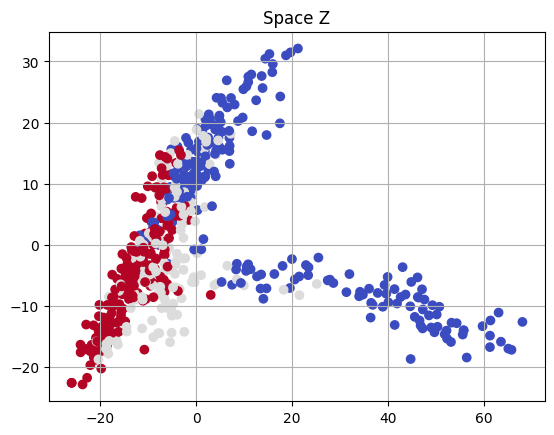

In [18]:
from sklearn.decomposition import PCA

Z = latent.Z_train.copy()
Y = latent.y_train.argmax(axis=1).copy()
Z = PCA().fit_transform(Z)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space Z')

Text(0.5, 1.0, 'Space W')

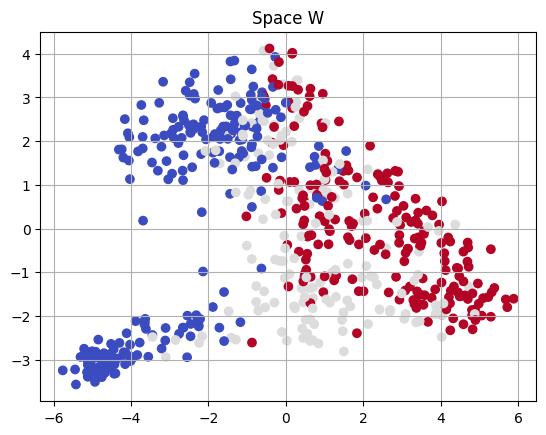

In [19]:
from sklearn.decomposition import PCA

W = latent.W_train.reshape(-1, np.prod(latent.W_train.shape[1:]))
Y = latent.y_train.argmax(axis=1).copy()
Z = PCA().fit_transform(W)

plt.scatter(Z[:,0], Z[:,1], c=Y, cmap='coolwarm')
plt.grid()
plt.title('Space W')

# Feature importance

In [31]:
latent.explain_linear(class_label=0, num_k=None)

Training Logistic Regression surrogate.
LR surrogate score: 0.9677


In [32]:
fimp = latent.get_feature_importance(X_test, Y_test_bb, class_label=0, num_k=None)

In [33]:
fimp = [[(f, ex[i]) for i,f in enumerate(feature_names)] for ex in fimp]

In [34]:
fimp[1][:10]

[('ARL11', 0.007674632175834754),
 ('ADAD2', 0.0005138865894651684),
 ('SPINK5', -0.006548468910954654),
 ('TRIM15', 0.0150106619107391),
 ('TARM1', -0.019532564915737394),
 ('DSG3', 0.009047776996391392),
 ('TNFAIP8', 0.018484902005224964),
 ('PABPC1L', -0.005164856506941965),
 ('C12orf54', -0.017533508034433865),
 ('ARHGAP12', -0.012776600268860865)]

# Decision Rules

In [38]:
latent.explain_dectree(class_label=0, num_k=2)

Training Decision Tree surrogate.
DT surrogate score: 0.8276


##### Factual rules

In [43]:
rules = latent.get_decision_rules(X_test, Y_test_bb, class_label=0, num_k=2)

In [44]:
rules = [[(feature_names[int(att[1:])], op, val) 
          for (att, op), val in inverse_transform_rule_complete(ex, train_data['scaler'], latent.idx_num).items()] for ex in rules]

In [37]:
rules = [[(f,eq, ex[(f,eq)]) if f in data_dict['numeric_columns'] 
          else (f.split('=')[0], ('=' if eq=='>' else '!='), f.split('=')[1]) 
          for f,eq in ex]
         for ex in rules]

In [53]:
rules[0]

[('EDN3', '>', -0.2105000854579099),
 ('MAP4K3', '>', -0.32594379765364717),
 ('GJB3', '>', 1.6296145794162418),
 ('UGT1A6', '>', 1.2449826468380603),
 ('PCDH11X', '<=', 0.5663326162307447),
 ('FAM83H', '>', -1.522739591474909),
 ('RRP1B', '<=', 0.714708385840694),
 ('MBTPS2', '<=', 0.2427301020102926)]

##### CounterRules/CounterExamples

In [47]:
crules, cfs = latent.get_counterfactuals(X_test, Y_test_bb, class_label=0, num_k=2)

In [48]:
crules = [[[(feature_names[int(att[1:])], op , val) 
            for (att, op), val in inverse_transform_rule_complete(cx, train_data['scaler'], latent.idx_num).items()] for cx in cx_list] for cx_list in crules]

In [49]:
crules[0]

[[('PLEKHB1', '<=', 2.231430267475642), ('C1orf116', '<=', 1.096133107561683)],
 [('EVL', '<=', 0.6745081774254774),
  ('OMD', '>', -1.2773134887928257),
  ('CLEC4C', '<=', 0.2239982404795627),
  ('SCGB1C2', '>', -0.052484003167294256)]]

In [51]:
cfs = [train_data['scaler'].inverse_transform(cf[:, latent.idx_num]) for cf in cfs]